In [1]:
# Import các thư viện cần thiết cho ML
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Đọc dữ liệu
columns = [
    "Age", "Gender", "Total_Bilirubin", "Direct_Bilirubin",
    "Alkaline_Phosphotase", "Alamine_Aminotransferase", "Aspartate_Aminotransferase",
    "Total_Protiens", "Albumin", "Albumin_and_Globulin_Ratio", "Liver cirrhosis"
]
df = pd.read_csv("Indian Liver Patient Dataset (ILPD).csv", header=None, names=columns)

display(df)

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Liver cirrhosis
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1
...,...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,2
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1


In [3]:
df['Liver cirrhosis'] = df['Liver cirrhosis'].map({1: 0, 2: 1}) 

In [4]:
# Thông tin tổng quan về DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    str    
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Liver cirrhosis             583 non-null    int64  
dtypes: float64(5), int64(5), str(1)
memory usage: 50.2 KB


In [5]:
# Thống kê mô tả
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,583.0,44.746141,16.189833,4.0,33.0,45.00,58.0,90.0
Total_Bilirubin,583.0,3.298799,6.209522,0.4,0.8,1.00,2.6,75.0
Direct_Bilirubin,583.0,1.486106,2.808498,0.1,0.2,0.30,1.3,19.7
Alkaline_Phosphotase,583.0,290.576329,242.937989,63.0,175.5,208.00,298.0,2110.0
Alamine_Aminotransferase,583.0,80.713551,182.620356,10.0,23.0,35.00,60.5,2000.0
Aspartate_Aminotransferase,583.0,109.910806,288.918529,10.0,25.0,42.00,87.0,4929.0
Total_Protiens,583.0,6.483190,1.085451,2.7,5.8,6.60,7.2,9.6
Albumin,583.0,3.141852,0.795519,0.9,2.6,3.10,3.8,5.5
Albumin_and_Globulin_Ratio,579.0,0.947064,0.319592,0.3,0.7,0.93,1.1,2.8
Liver cirrhosis,583.0,0.286449,0.452490,0.0,0.0,0.00,1.0,1.0


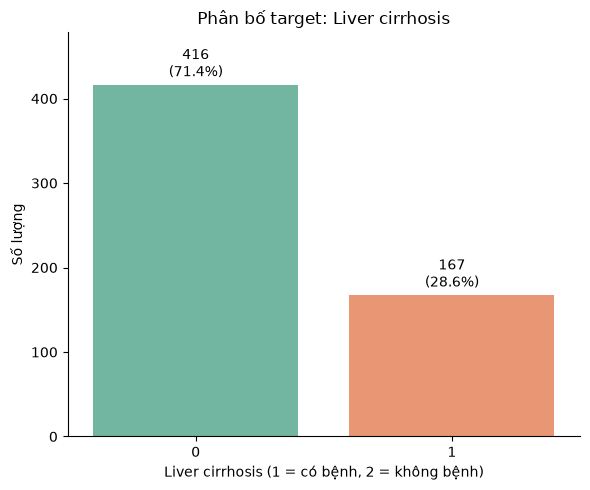

In [6]:
# Bar plot: phân bố target Liver cirrhosis (số đếm + %)
counts = df['Liver cirrhosis'].value_counts().sort_index()
pct = counts / counts.sum() * 100
labels = [f'{c}\n({p:.1f}%)' for c, p in zip(counts.values, pct.values)]

plt.figure(figsize=(6, 5))
ax = sns.barplot(
    x=counts.index.astype(str), y=counts.values,
    hue=counts.index.astype(str), palette='Set2', legend=False
)

# seaborn 0.13 tách mỗi cột thành 1 container riêng -> label từng cái
for container, lbl in zip(ax.containers, labels):
    ax.bar_label(container, labels=[lbl], padding=3)

ax.set_title('Phân bố target: Liver cirrhosis')
ax.set_xlabel('Liver cirrhosis (1 = có bệnh, 2 = không bệnh)')
ax.set_ylabel('Số lượng')
ax.set_ylim(0, counts.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

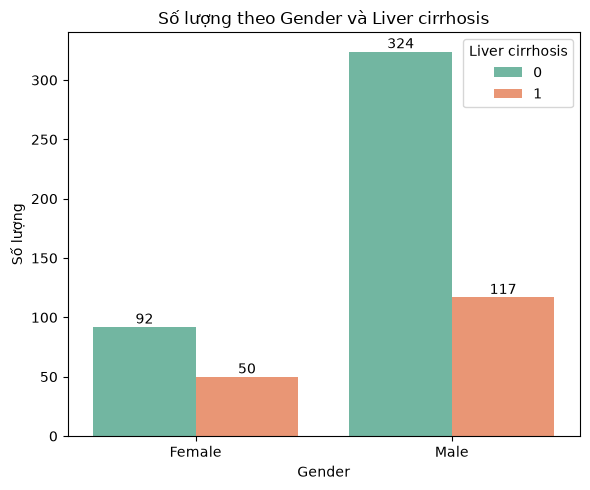

In [7]:
# Bar chart: số lượng theo Gender, phân theo target
plt.figure(figsize=(6, 5))
ax = sns.countplot(data=df, x='Gender', hue='Liver cirrhosis', palette='Set2')
ax.set_title('Số lượng theo Gender và Liver cirrhosis')
ax.set_xlabel('Gender')
ax.set_ylabel('Số lượng')
ax.legend(title='Liver cirrhosis')

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

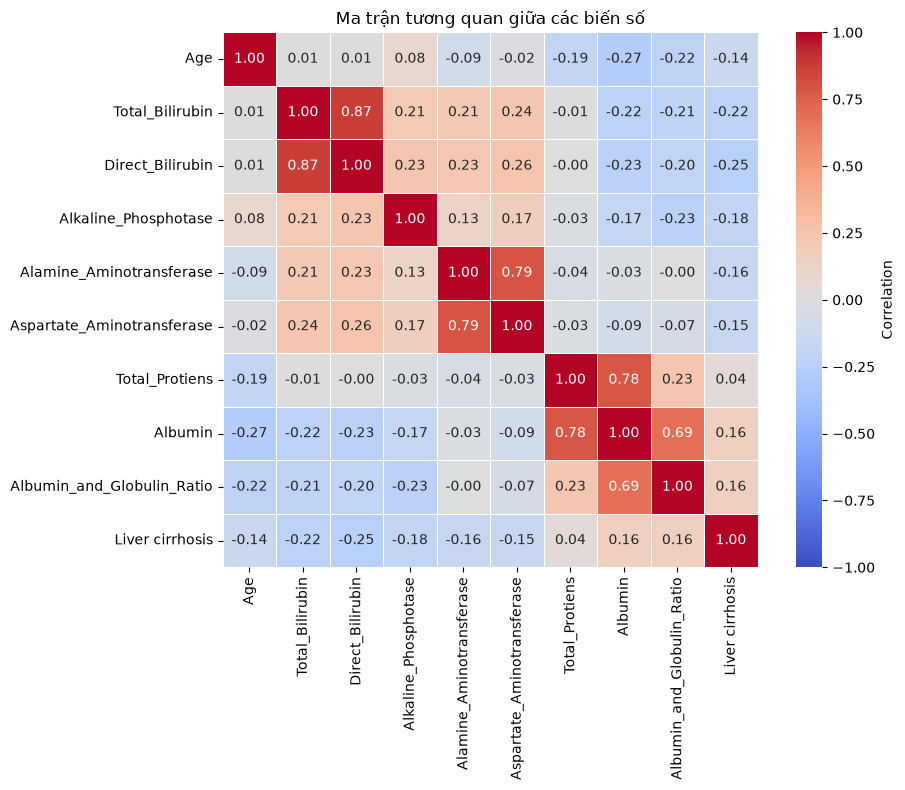

In [8]:
# Ma trận tương quan (bỏ cột Gender vì không phải số)
corr = df.drop(columns=['Gender']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws={'label': 'Correlation'}
)
plt.title('Ma trận tương quan giữa các biến số')
plt.tight_layout()
plt.show()

In [9]:
# Kiểm định Chi-square: H0 = tỉ lệ mắc bệnh không khác nhau giữa hai giới tính
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['Gender'], df['Liver cirrhosis'])
print("Bảng tần số quan sát:")
display(contingency)

chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"\nChi-square statistic: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Bậc tự do: {dof}")
print("\nBảng tần số kỳ vọng (cần >= 5 để Chi-square hợp lệ):")
display(pd.DataFrame(expected, index=contingency.index, columns=contingency.columns).round(2))

alpha = 0.05
if p_value < alpha:
    print(f"\np-value ({p_value:.4f}) < {alpha} => Bác bỏ H0: có sự khác biệt về tỉ lệ mắc bệnh giữa hai giới tính.")
else:
    print(f"\np-value ({p_value:.4f}) >= {alpha} => Không đủ bằng chứng bác bỏ H0: chưa thấy khác biệt về tỉ lệ mắc bệnh giữa hai giới tính.")

Bảng tần số quan sát:


Liver cirrhosis,0,1
Gender,,
Female,92,50
Male,324,117



Chi-square statistic: 3.5466
p-value: 0.0597
Bậc tự do: 1

Bảng tần số kỳ vọng (cần >= 5 để Chi-square hợp lệ):


Liver cirrhosis,0,1
Gender,,
Female,101.32,40.68
Male,314.68,126.32



p-value (0.0597) >= 0.05 => Không đủ bằng chứng bác bỏ H0: chưa thấy khác biệt về tỉ lệ mắc bệnh giữa hai giới tính.


In [10]:
# Cramér's V: đo độ mạnh của mối liên hệ giữa Gender và Liver cirrhosis
import numpy as np

# Dùng chi2 không hiệu chỉnh Yates cho effect size (chuẩn khi tính Cramér's V)
chi2_raw, p_raw, dof_raw, _ = chi2_contingency(contingency, correction=False)

n = contingency.to_numpy().sum()
r, k = contingency.shape
cramers_v = np.sqrt(chi2_raw / (n * (min(r, k) - 1)))

print(f"Chi-square (không hiệu chỉnh): {chi2_raw:.4f}, p-value: {p_raw:.4f}")
print(f"Cramér's V: {cramers_v:.4f}")

# Ngưỡng tham khảo (Cohen, cho bảng 2x2 / dof=1)
if cramers_v < 0.1:
    strength = "rất yếu / không đáng kể"
elif cramers_v < 0.3:
    strength = "yếu"
elif cramers_v < 0.5:
    strength = "trung bình"
else:
    strength = "mạnh"

print(f"=> Mức độ liên hệ: {strength}")

Chi-square (không hiệu chỉnh): 3.9600, p-value: 0.0466
Cramér's V: 0.0824
=> Mức độ liên hệ: rất yếu / không đáng kể


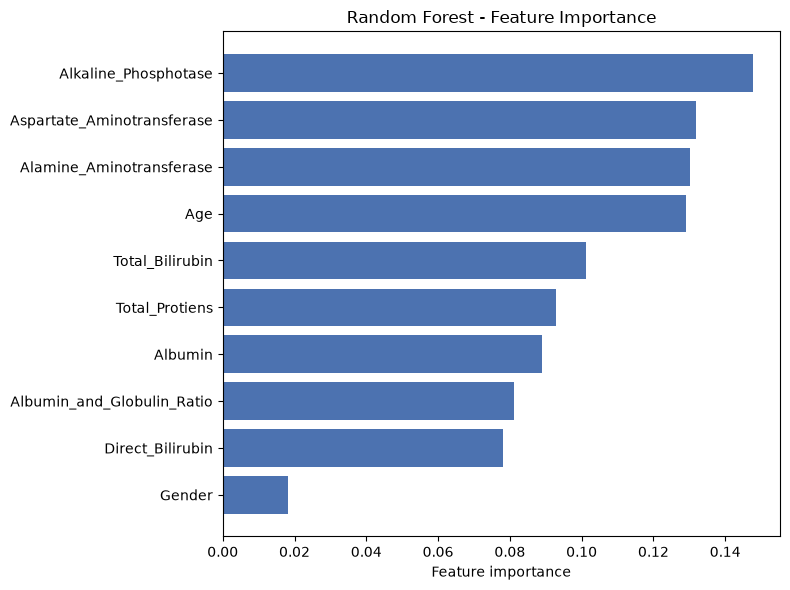

Alkaline_Phosphotase          0.147870
Aspartate_Aminotransferase    0.131975
Alamine_Aminotransferase      0.130317
Age                           0.129178
Total_Bilirubin               0.101335
Total_Protiens                0.092962
Albumin                       0.089048
Albumin_and_Globulin_Ratio    0.081059
Direct_Bilirubin              0.078092
Gender                        0.018165
dtype: float64

In [11]:
# Feature importance với Random Forest
from sklearn.ensemble import RandomForestClassifier

df_model = df.copy()
df_model['Gender'] = df_model['Gender'].map({'Male': 1, 'Female': 0})
df_model['Albumin_and_Globulin_Ratio'] = df_model['Albumin_and_Globulin_Ratio'].fillna(
    df_model['Albumin_and_Globulin_Ratio'].median()
)

X = df_model.drop(columns=['Liver cirrhosis'])
y = df_model['Liver cirrhosis']

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(importances.index, importances.values, color='#4C72B0')
plt.xlabel('Feature importance')
plt.title('Random Forest - Feature Importance')
plt.tight_layout()
plt.show()

importances.sort_values(ascending=False)

In [12]:
# VIF (Variance Inflation Factor): kiểm tra đa cộng tuyến giữa các feature
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X.copy()
X_vif.insert(0, 'const', 1.0)  # VIF cần cột hằng số để chuẩn xác

vif_df = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_df = vif_df[vif_df['Feature'] != 'const'].sort_values('VIF', ascending=False).reset_index(drop=True)

vif_df

,Feature,VIF
0,Albumin,10.124110
1,Total_Protiens,5.549387
2,Direct_Bilirubin,4.525273
3,Total_Bilirubin,4.277109
4,Albumin_and_Globulin_Ratio,3.682718
5,Alamine_Aminotransferase,2.820379
6,Aspartate_Aminotransferase,2.810927
7,Alkaline_Phosphotase,1.121710
8,Age,1.099327
9,Gender,1.033815


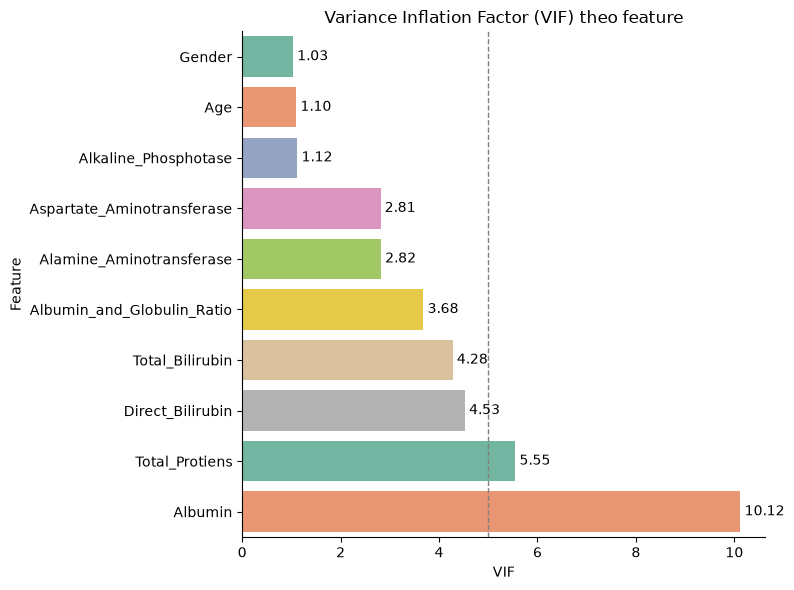

In [13]:
# Bar plot VIF theo feature
plt.figure(figsize=(8, 6))
ax = sns.barplot(data=vif_df.sort_values('VIF'), y='Feature', x='VIF',
                 hue='Feature', palette='Set2', legend=False)
ax.axvline(5, color='gray', linestyle='--', linewidth=1)
ax.set_title('Variance Inflation Factor (VIF) theo feature')

# seaborn 0.13 tách mỗi bar thành 1 container riêng (do hue) -> label từng cái
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

sns.despine()
plt.tight_layout()
plt.show()

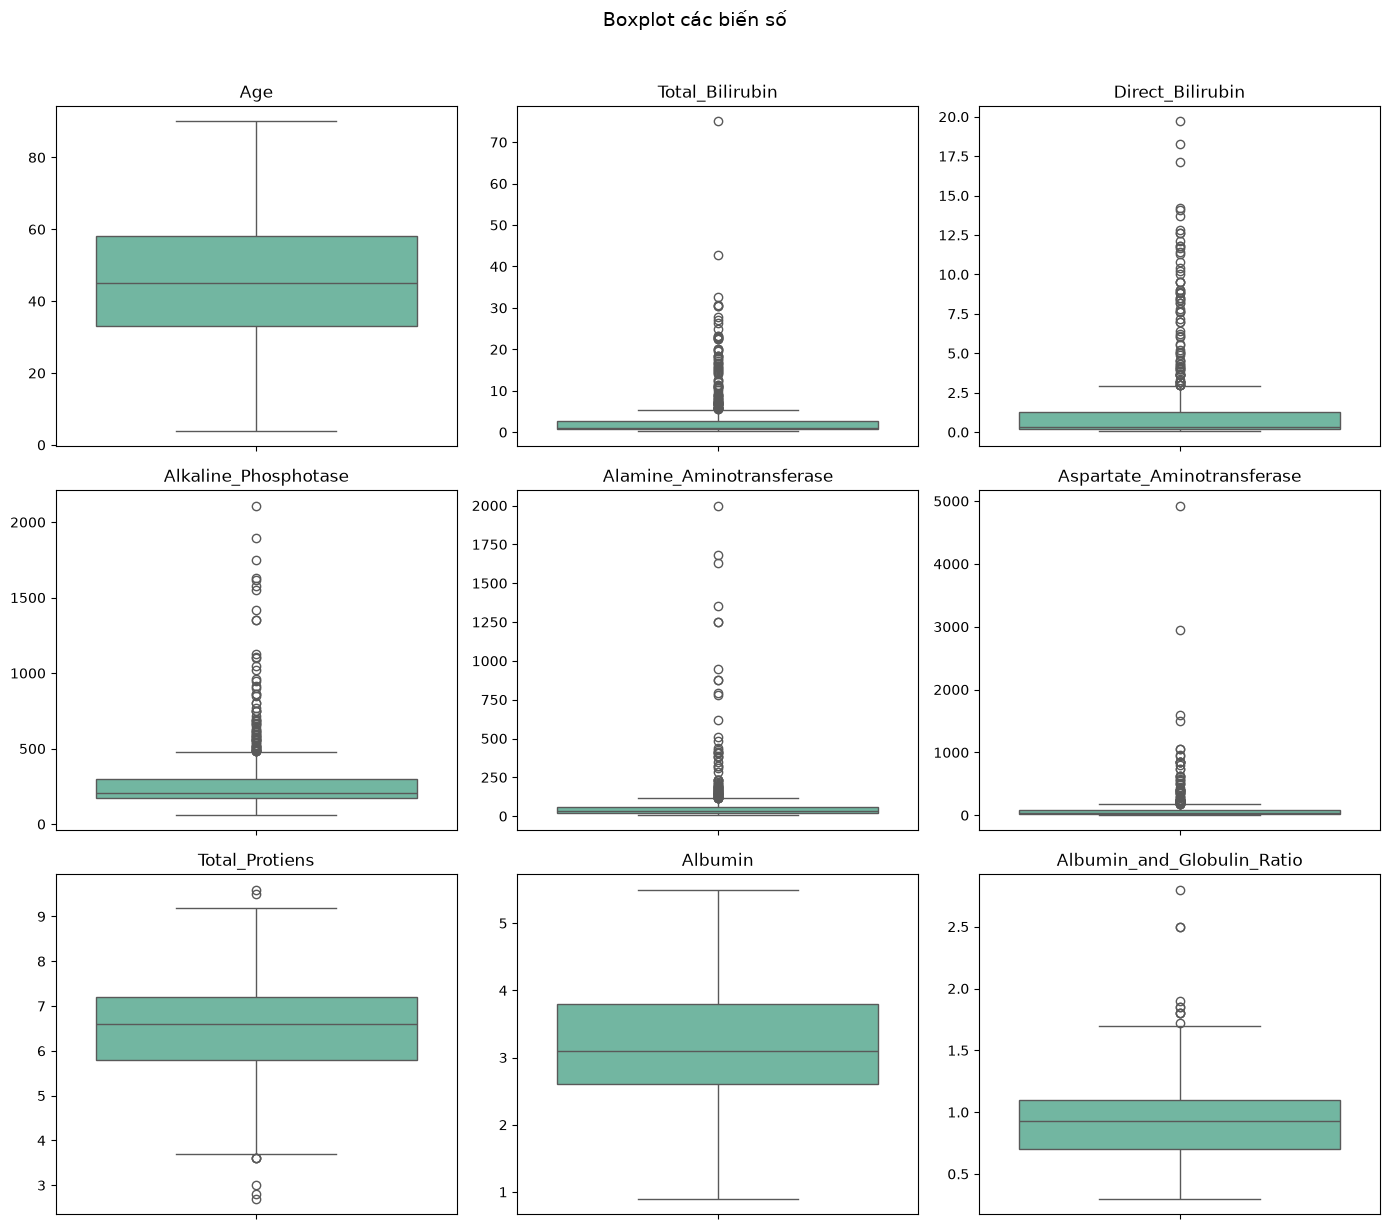

In [14]:
# Boxplot cho 9 biến số (bỏ Gender và Liver cirrhosis)
numeric_cols = df.drop(columns=['Gender', 'Liver cirrhosis']).columns

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color='#66c2a5')
    ax.set_title(col)
    ax.set_ylabel('')

plt.suptitle('Boxplot các biến số', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
# Thống kê (min, max, mean, median, std) theo từng nhóm target
numeric_cols = df.drop(columns=['Gender', 'Liver cirrhosis']).columns

group_stats = df.groupby('Liver cirrhosis')[numeric_cols].agg(
    ['min', 'max', 'mean', 'median', 'std']
).round(2).T

group_stats

Liver cirrhosis                          0        1
Age                        min        7.00     4.00
                           max       90.00    85.00
                           mean      46.15    41.24
                           median    46.00    40.00
                           std       15.65    17.00
Total_Bilirubin            min        0.40     0.50
                           max       75.00     7.30
                           mean       4.16     1.14
                           median     1.40     0.80
                           std        7.14     1.00
Direct_Bilirubin           min        0.10     0.10
                           max       19.70     3.60
                           mean       1.92     0.40
                           median     0.50     0.20
                           std        3.21     0.52
Alkaline_Phosphotase       min       63.00    90.00
                           max     2110.00  1580.00
                           mean     319.01   219.75
                           median   229.00   186.00
                           std      268.31   140.99
Alamine_Aminotransferase   min       12.00    10.00
                           max     2000.00   181.00
                           mean      99.61    33.65
                           median    41.00    27.00
                           std      212.77    25.06
Aspartate_Aminotransferase min       11.00    10.00
                           max     4929.00   285.00
                           mean     137.70    40.69
                           median    52.50    29.00
                           std      337.39    36.41
Total_Protiens             min        2.70     3.70
                           max        9.60     9.20
                           mean       6.46     6.54
                           median     6.55     6.60
                           std        1.09     1.06
Albumin                    min        0.90     1.40
                           max        5.50     5.00
                           mean       3.06     3.34
                           median     3.00     3.40
                           std        0.79     0.78
Albumin_and_Globulin_Ratio min        0.30     0.37
                           max        2.80     1.90
                           mean       0.91     1.03
                           median     0.90     1.00
                           std        0.33     0.29